In [ ]:
"""
Garmin clean_dataset_final.csv EDA

This script is designed for Google Colab, but it also runs locally.
It reads clean_dataset_final.csv, prints basic checks, saves summary tables,
and exports all requested charts as PNG files into eda_outputs/.
"""

import argparse
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


# If a local environment is missing packages, install them with:
#   pip install pandas matplotlib seaborn
# Google Colab usually includes these packages by default.

# =========================
# 1. Load data
# =========================
parser = argparse.ArgumentParser(description="Run EDA for Garmin clean dataset.")
parser.add_argument(
    "--csv",
    default="clean_dataset_final.csv",
    help=(
        "Path to clean_dataset_final.csv. In Google Colab, upload the file to "
        "the current working directory and keep the default value."
    ),
)
args, _ = parser.parse_known_args()

# In Google Colab, upload clean_dataset_final.csv to the current working
# directory, mount Google Drive and pass --csv, or change the default above.
CSV_PATH = args.csv
OUTPUT_DIR = Path("eda_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(CSV_PATH)
df["date"] = pd.to_datetime(df["date"], errors="coerce")


# =========================
# 2. Basic data checks
# =========================
print("Dataset shape (rows, columns):")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

missing_values = df.isna().sum().sort_values(ascending=False)
print("\nMissing values:")
print(missing_values)
missing_values.to_csv(OUTPUT_DIR / "missing_values.csv", header=["missing_count"])


# =========================
# 3. Descriptive statistics
# =========================
descriptive_stats = df.describe(include="all").transpose()
print("\nDescriptive statistics:")
print(descriptive_stats)
descriptive_stats.to_csv(OUTPUT_DIR / "descriptive_statistics.csv")


# Shared plotting style
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 120


def save_current_figure(filename: str) -> None:
    """Save the active matplotlib figure and close it."""
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, bbox_inches="tight")
    plt.close()


# =========================
# 4. body_battery_status bar chart
# =========================
plt.figure(figsize=(8, 5))
status_order = df["body_battery_status"].value_counts().index
ax = sns.countplot(data=df, x="body_battery_status", order=status_order)
ax.set_title("Distribution of Body Battery Status")
ax.set_xlabel("Body Battery Status")
ax.set_ylabel("Count")
for container in ax.containers:
    ax.bar_label(container)
save_current_figure("body_battery_status_distribution.png")


# =========================
# 5. Distribution plots
# =========================
distribution_columns = [
    "sleep_hours",
    "steps",
    "sedentary_ratio",
    "resting_heart_rate",
]

for column in distribution_columns:
    plt.figure(figsize=(8, 5))
    ax = sns.histplot(data=df, x=column, kde=True, bins=30)
    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Count")
    save_current_figure(f"{column}_distribution.png")


# =========================
# 6. Boxplots by body_battery_status
# =========================
for column in distribution_columns:
    plt.figure(figsize=(8, 5))
    ax = sns.boxplot(
        data=df,
        x="body_battery_status",
        y=column,
        order=status_order,
    )
    ax.set_title(f"{column} by Body Battery Status")
    ax.set_xlabel("Body Battery Status")
    ax.set_ylabel(column)
    save_current_figure(f"{column}_by_body_battery_status_boxplot.png")


# =========================
# 7. Scatter plots
# =========================
scatter_pairs = [
    ("sleep_hours", "steps"),
    ("awake_ratio", "sedentary_ratio"),
    ("deep_sleep_ratio", "active_time"),
    ("sleep_efficiency", "resting_heart_rate"),
]

for x_col, y_col in scatter_pairs:
    plt.figure(figsize=(8, 5))
    ax = sns.scatterplot(
        data=df,
        x=x_col,
        y=y_col,
        hue="body_battery_status",
        alpha=0.75,
    )
    ax.set_title(f"{x_col} vs {y_col}")
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.legend(title="Body Battery Status", bbox_to_anchor=(1.02, 1), loc="upper left")
    save_current_figure(f"{x_col}_vs_{y_col}_scatter.png")


# =========================
# 8. Correlation heatmap
# =========================
numeric_df = df.select_dtypes(include="number")
correlation_matrix = numeric_df.corr()
correlation_matrix.to_csv(OUTPUT_DIR / "correlation_matrix.csv")

plt.figure(figsize=(14, 10))
ax = sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"},
)
ax.set_title("Correlation Heatmap of Numeric Features")
save_current_figure("correlation_heatmap.png")


print(f"\nEDA completed. Outputs saved to: {OUTPUT_DIR.resolve()}")

Dataset shape (rows, columns):
(801, 18)

Columns:
['id', 'date', 'steps', 'active_kilocalories', 'active_time', 'resting_heart_rate', 'average_heart_rate', 'sleep_hours', 'deep_sleep_ratio', 'rem_ratio', 'awake_ratio', 'sleep_efficiency', 'sedentary_ratio', 'active_ratio', 'highly_active_ratio', 'body_battery_status', 'total_sport_hours', 'stress_hours']

Data types:
id                             object
date                   datetime64[ns]
steps                         float64
active_kilocalories           float64
active_time                   float64
resting_heart_rate            float64
average_heart_rate            float64
sleep_hours                   float64
deep_sleep_ratio              float64
rem_ratio                     float64
awake_ratio                   float64
sleep_efficiency              float64
sedentary_ratio               float64
active_ratio                  float64
highly_active_ratio           float64
body_battery_status            object
total_sport_hours    

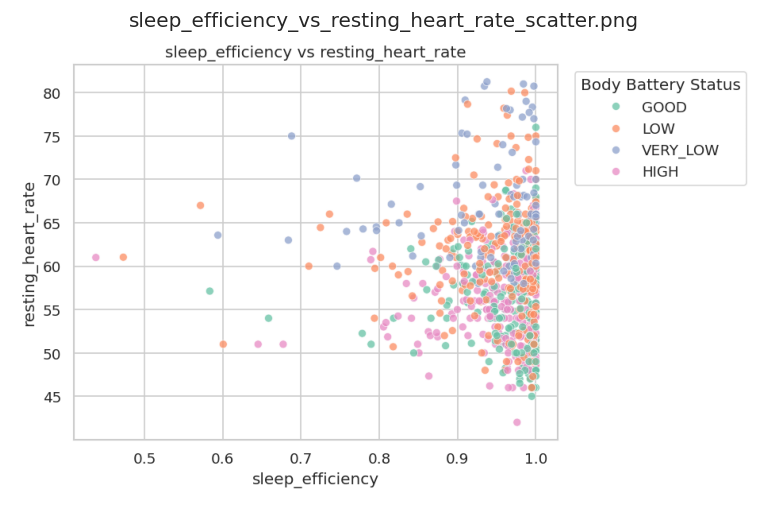

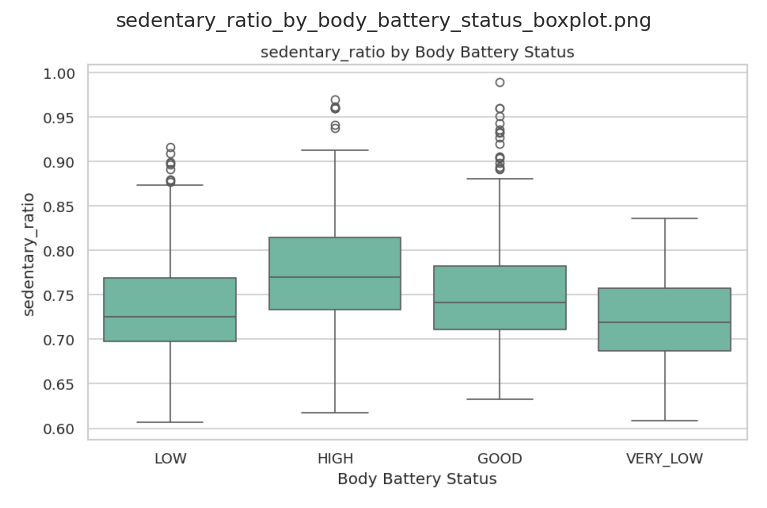

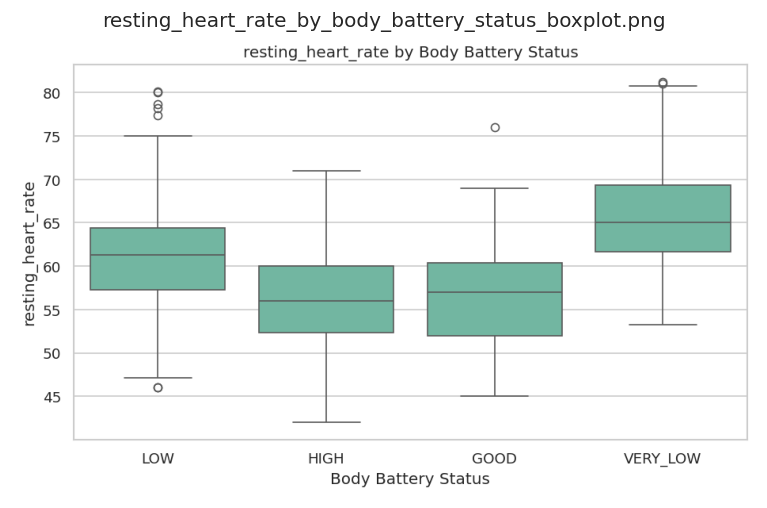

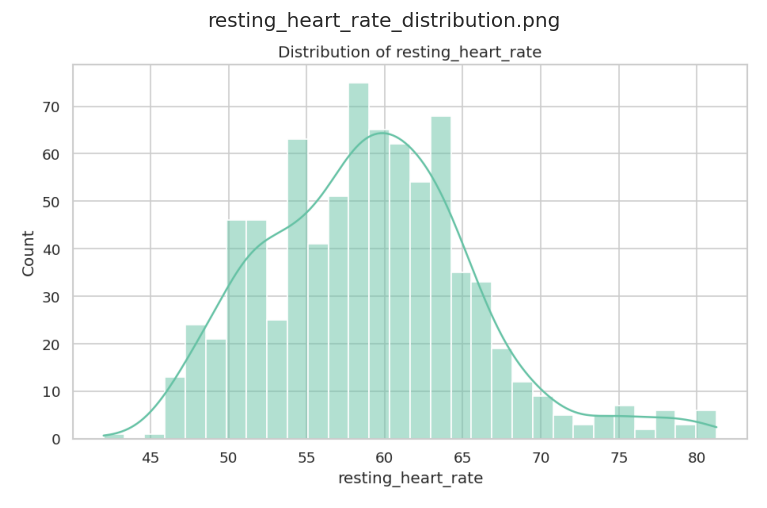

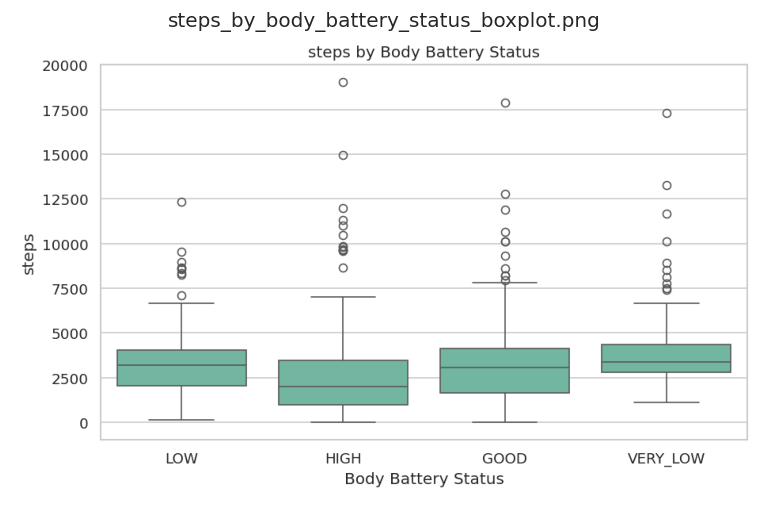

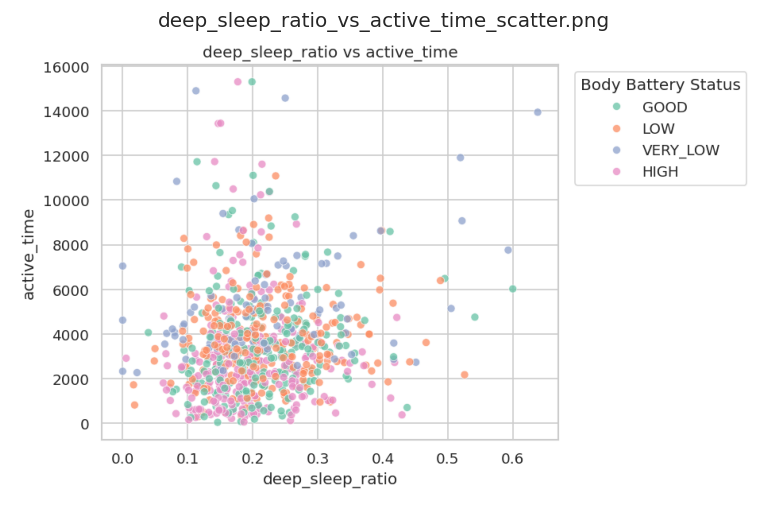

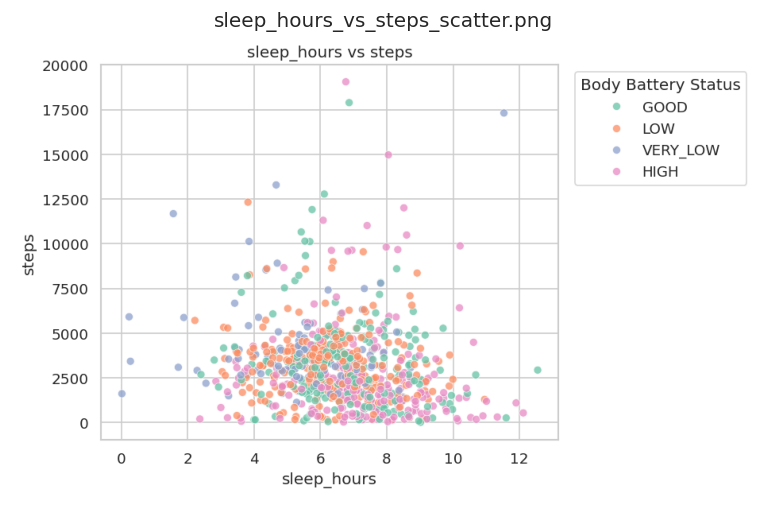

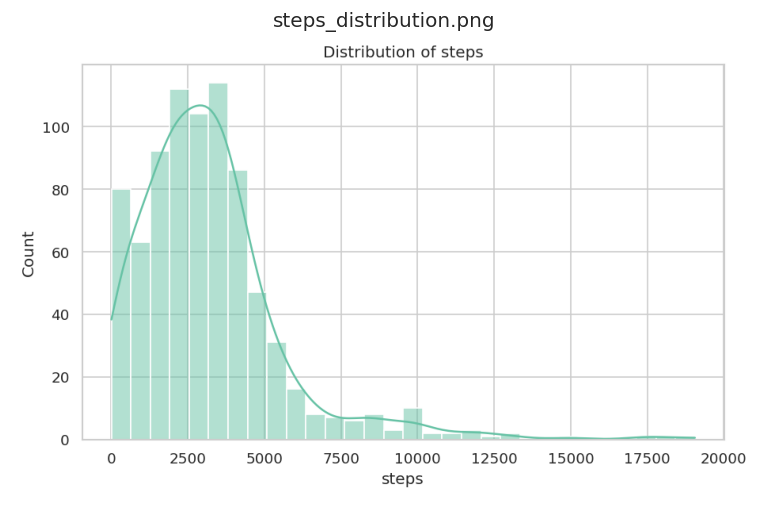

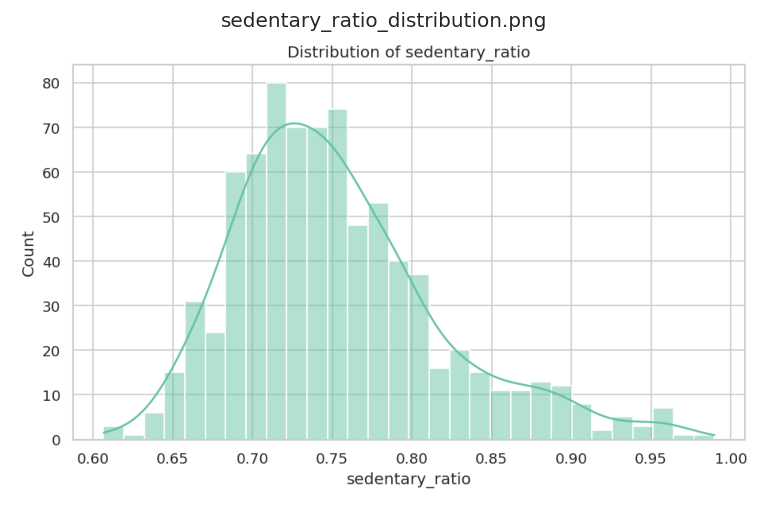

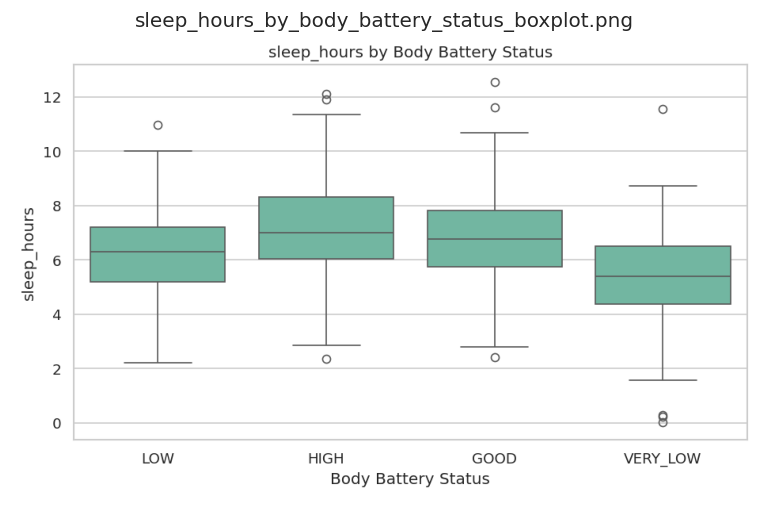

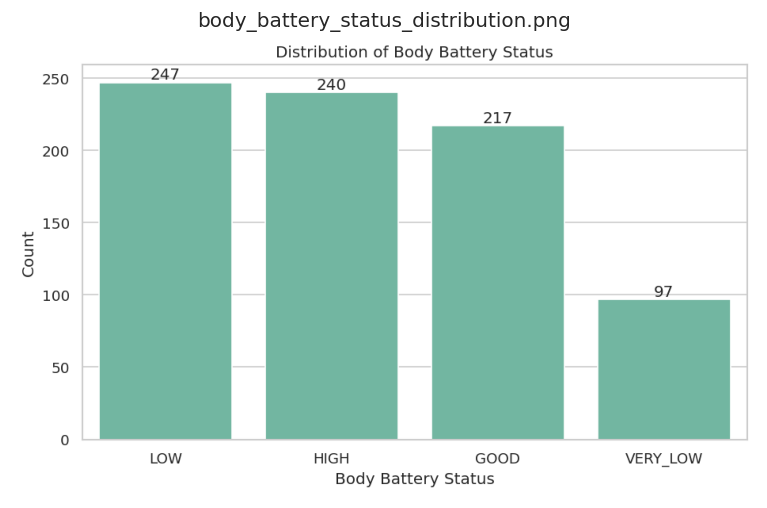

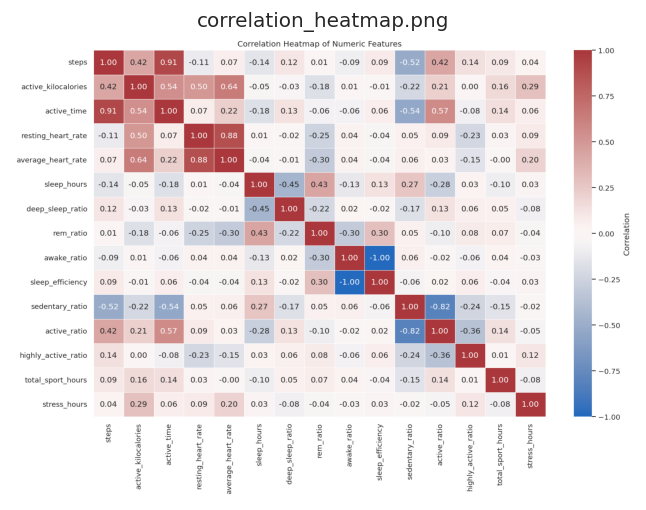

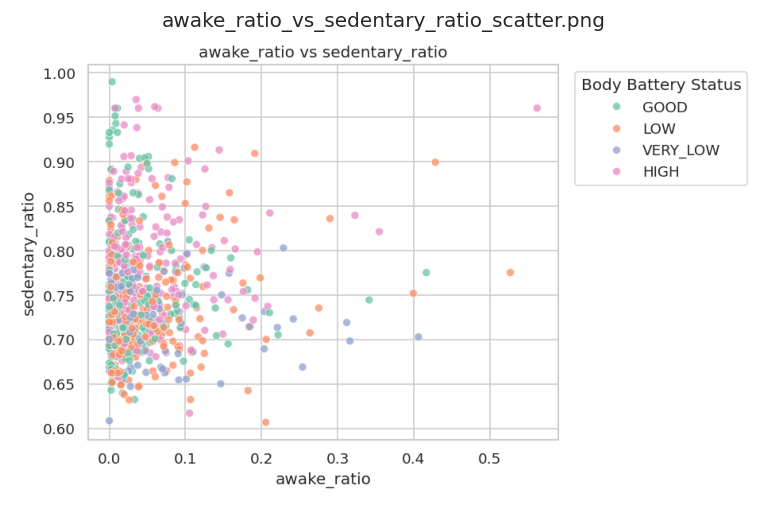

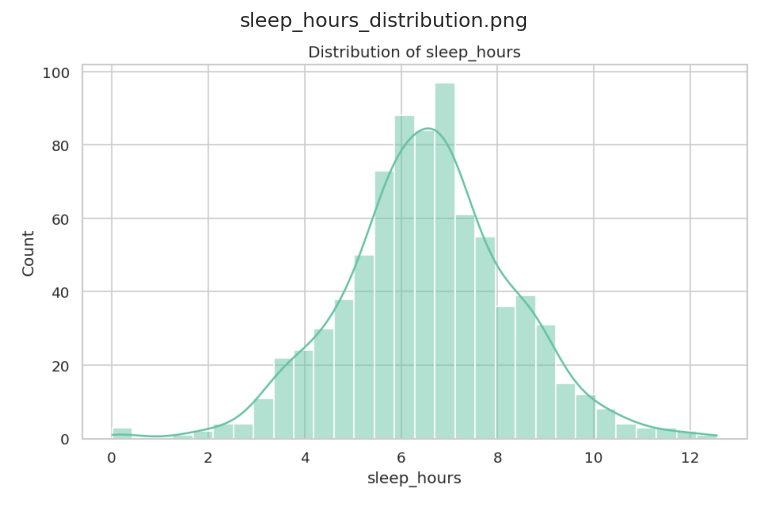

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os

files = os.listdir("/content/eda_outputs")

for f in files:
    if f.endswith(".png"):
        img = Image.open("/content/eda_outputs/" + f)
        plt.figure(figsize=(8,5))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f)
        plt.show()

In [ ]:
!zip -r eda_outputs.zip eda_outputs

  adding: eda_outputs/ (stored 0%)
  adding: eda_outputs/sleep_efficiency_vs_resting_heart_rate_scatter.png (deflated 3%)
  adding: eda_outputs/missing_values.csv (deflated 49%)
  adding: eda_outputs/sedentary_ratio_by_body_battery_status_boxplot.png (deflated 17%)
  adding: eda_outputs/resting_heart_rate_by_body_battery_status_boxplot.png (deflated 17%)
  adding: eda_outputs/resting_heart_rate_distribution.png (deflated 9%)
  adding: eda_outputs/steps_by_body_battery_status_boxplot.png (deflated 18%)
  adding: eda_outputs/deep_sleep_ratio_vs_active_time_scatter.png (deflated 3%)
  adding: eda_outputs/sleep_hours_vs_steps_scatter.png (deflated 3%)
  adding: eda_outputs/descriptive_statistics.csv (deflated 53%)
  adding: eda_outputs/steps_distribution.png (deflated 10%)
  adding: eda_outputs/correlation_matrix.csv (deflated 69%)
  adding: eda_outputs/sedentary_ratio_distribution.png (deflated 9%)
  adding: eda_outputs/sleep_hours_by_body_battery_status_boxplot.png (deflated 18%)
  addin

In [ ]:
from google.colab import files
files.download("eda_outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>